In [1]:
# CodeAlpha - Task 1: Credit Scoring Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [10]:
df = pd.read_csv("/content/german_credit_data_updated.csv")

print("Dataset loaded successfully! ✅")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully! ✅
Shape: (954, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


In [6]:
import os

print(os.listdir("/content"))

['.config', 'german_credit_data_updated.csv', 'sample_data']


In [7]:
df = pd.read_csv("/content/german_credit_data_updated.csv")

print("Dataset loaded successfully! ✅")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully! ✅
Shape: (954, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


In [8]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (954, 11)

Columns:
['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Credit Risk']


In [9]:
print("\nCredit Risk:")
print(df["Credit Risk"].value_counts())


Credit Risk:
Credit Risk
1    665
2    289
Name: count, dtype: int64


In [11]:
import pandas as pd

df = pd.read_csv("/content/german_credit_data_updated.csv")

print("Dataset loaded successfully! ✅")
print("Shape:", df.shape)

Dataset loaded successfully! ✅
Shape: (954, 11)


In [12]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Credit Risk']


In [13]:
print("Credit Risk distribution:")
print(df["Credit Risk"].value_counts())

Credit Risk distribution:
Credit Risk
1    665
2    289
Name: count, dtype: int64


In [14]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     175
Checking account    378
Credit amount         0
Duration              0
Purpose               0
Credit Risk           0
dtype: int64


In [15]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (954, 11)

Data Types:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Credit Risk          int64
dtype: object

First 5 rows:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


In [16]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Saving accounts     175
Checking account    378
dtype: int64


Credit Risk Distribution:
Credit Risk
1    665
2    289
Name: count, dtype: int64


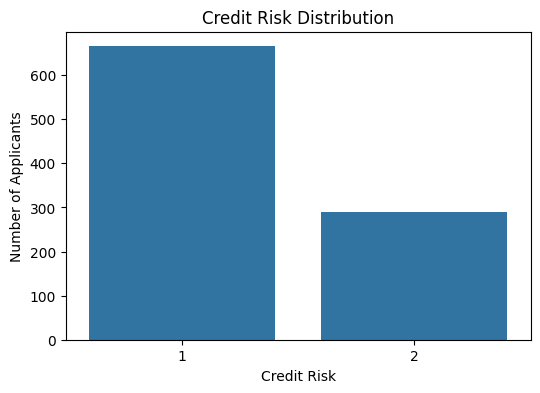

In [17]:
print("Credit Risk Distribution:")
print(df["Credit Risk"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Credit Risk")
plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Applicants")
plt.show()

In [18]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration,Credit Risk
count,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000
mean,476.500000,35.501048,1.909853,3279.112159,20.780922,1.302935
std,275.540378,11.379668,0.649681,2853.315158,12.046483,0.459768
min,0.000000,19.000000,0.000000,250.000000,4.000000,1.000000
25%,238.250000,27.000000,2.000000,1360.250000,12.000000,1.000000
50%,476.500000,33.000000,2.000000,2302.500000,18.000000,1.000000
75%,714.750000,42.000000,2.000000,3975.250000,24.000000,2.000000
max,953.000000,75.000000,3.000000,18424.000000,72.000000,2.000000


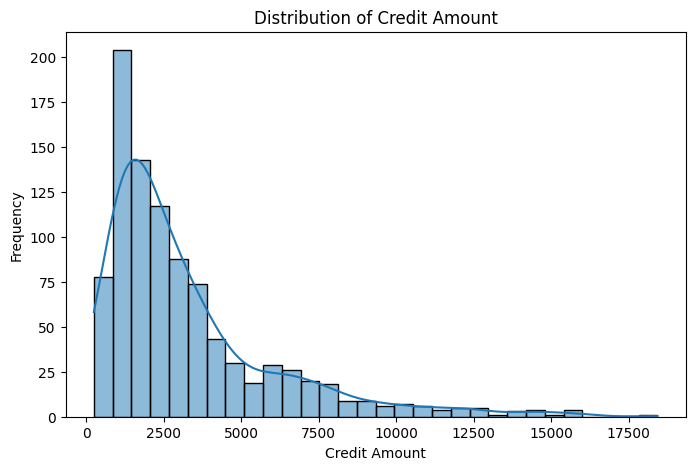

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Credit amount"], bins=30, kde=True)
plt.title("Distribution of Credit Amount")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

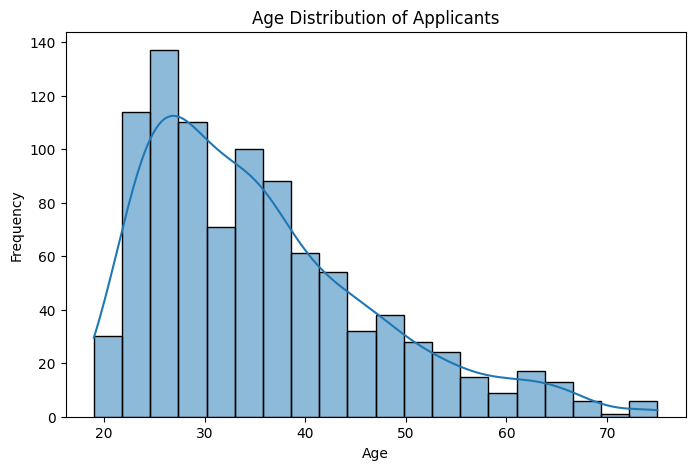

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Applicants")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

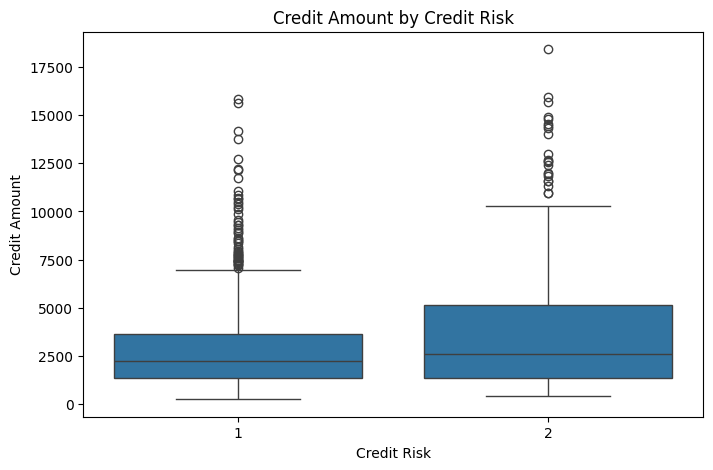

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Credit Risk", y="Credit amount")
plt.title("Credit Amount by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")
plt.show()

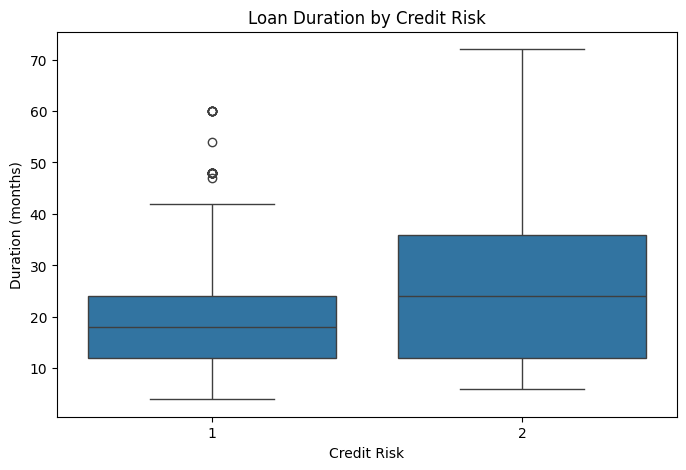

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Credit Risk", y="Duration")
plt.title("Loan Duration by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Duration (months)")
plt.show()

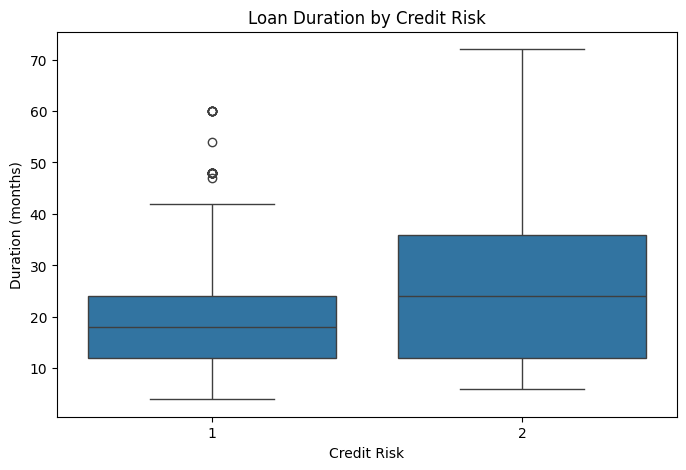

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Credit Risk", y="Duration")
plt.title("Loan Duration by Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Duration (months)")
plt.show()

In [25]:
# Create a working copy of the dataset
data = df.copy()

# Remove unwanted index columns if present
data = data.loc[:, ~data.columns.str.contains("^Unnamed")]

print("Data created successfully! ✅")
print("Shape:", data.shape)
print("Columns:")
print(data.columns.tolist())

Data created successfully! ✅
Shape: (954, 10)
Columns:
['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Credit Risk']


In [26]:
data["Credit Risk"] = data["Credit Risk"].map({
    1: 0,   # Good credit
    2: 1    # Poor credit
})

print("Credit Risk converted successfully! ✅")
print(data["Credit Risk"].value_counts())

Credit Risk converted successfully! ✅
Credit Risk
0    665
1    289
Name: count, dtype: int64


In [27]:
print(data.head())
print("\nMissing values:")
print(data.isnull().sum())

   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  Credit Risk  
0         6             radio/TV            0  
1        48             radio/TV            1  
2        12            education            0  
3        42  furniture/equipment            0  
4        24                  car            1  

Missing values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     175
Checking account    378
Credit amount         0
Duration              0
Purpose               0
Cred

In [28]:
X = data.drop("Credit Risk", axis=1)
y = data["Credit Risk"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (954, 9)
Target: (954,)


In [29]:
numeric_features = [
    "Age",
    "Credit amount",
    "Duration"
]

categorical_features = [
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Credit amount', 'Duration']

Categorical features:
['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [30]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully! ✅")

Preprocessing pipeline created successfully! ✅


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 763
Testing samples: 191

Training target distribution:
Credit Risk
0    532
1    231
Name: count, dtype: int64

Testing target distribution:
Credit Risk
0    133
1     58
Name: count, dtype: int64


In [32]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully! ✅")

Logistic Regression trained successfully! ✅


In [33]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Good Credit", "Poor Credit"]
))

              precision    recall  f1-score   support

 Good Credit       0.73      0.93      0.82       133
 Poor Credit       0.55      0.19      0.28        58

    accuracy                           0.71       191
   macro avg       0.64      0.56      0.55       191
weighted avg       0.67      0.71      0.65       191



In [34]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.7068
Precision: 0.5500
Recall   : 0.1897
F1-Score : 0.2821
ROC-AUC  : 0.6085


In [35]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully! ✅")

Random Forest trained successfully! ✅


In [36]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Good Credit", "Poor Credit"]
))

              precision    recall  f1-score   support

 Good Credit       0.73      0.91      0.81       133
 Poor Credit       0.52      0.22      0.31        58

    accuracy                           0.70       191
   macro avg       0.62      0.57      0.56       191
weighted avg       0.67      0.70      0.66       191



In [37]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.7016
Precision: 0.5200
Recall   : 0.2241
F1-Score : 0.3133
ROC-AUC  : 0.6348


In [38]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7068,0.55,0.1897,0.2821,0.6085
1,Random Forest,0.7016,0.52,0.2241,0.3133,0.6348


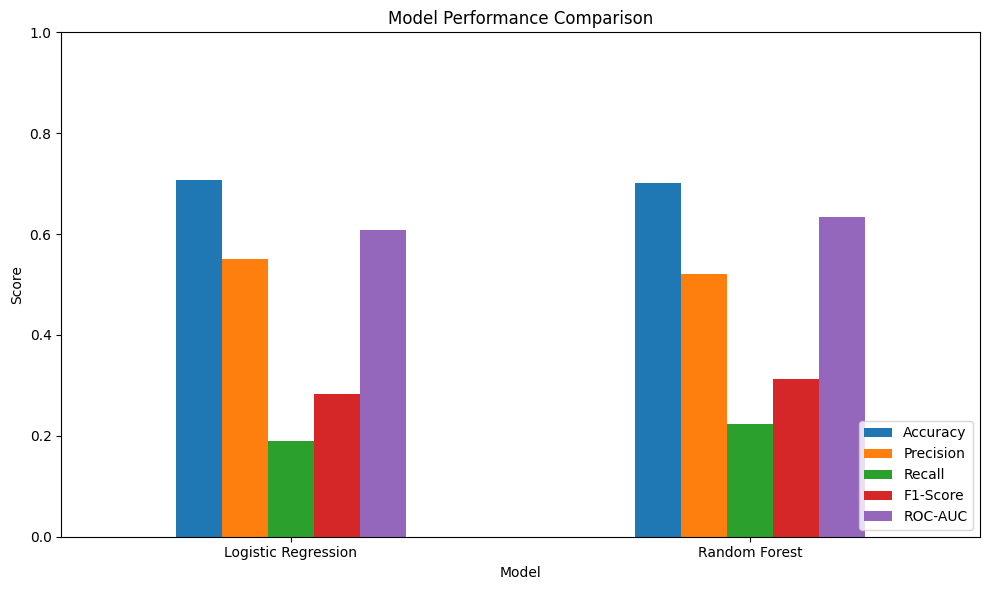

In [39]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

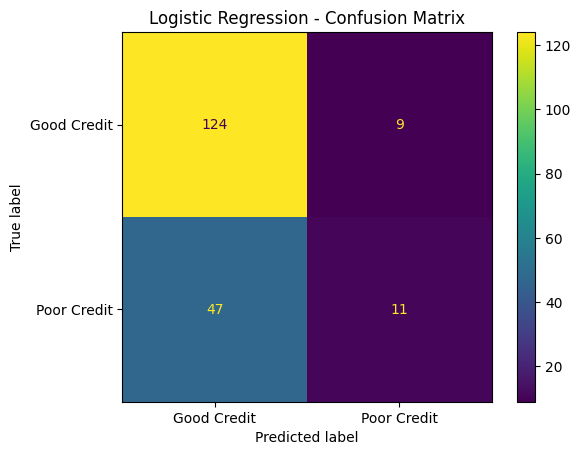

In [40]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Good Credit", "Poor Credit"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

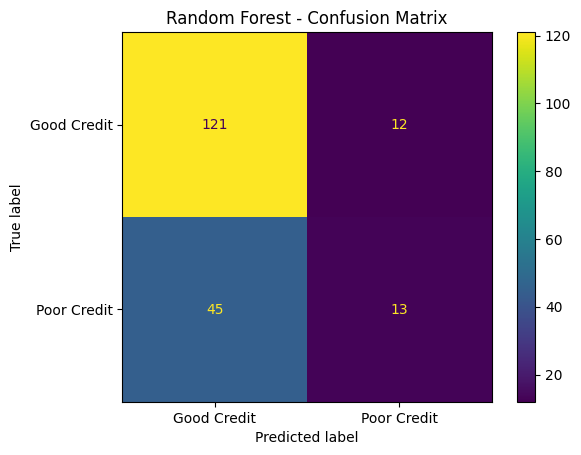

In [41]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Good Credit", "Poor Credit"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

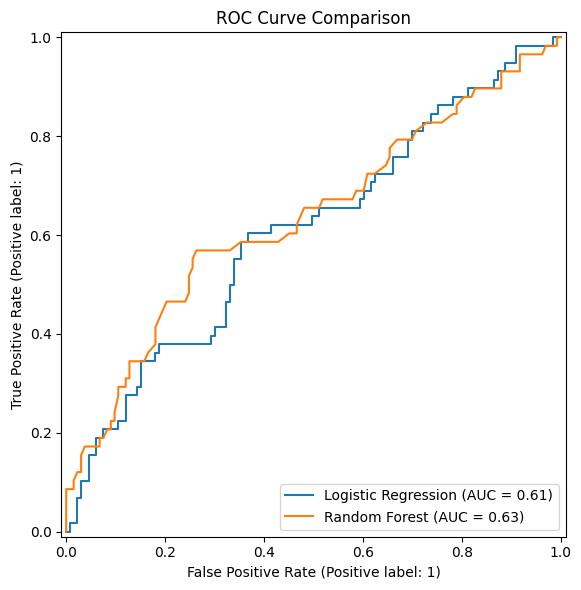

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest",
    ax=ax
)

ax.set_title("ROC Curve Comparison")
plt.tight_layout()

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
best_model_name = results.loc[
    results["F1-Score"].idxmax(),
    "Model"
]

print("Best model based on F1-Score:", best_model_name)

Best model based on F1-Score: Random Forest


In [44]:
rf_classifier = random_forest_model.named_steps["classifier"]
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

In [45]:
feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,num__Credit amount,0.232129
0,num__Age,0.190771
2,num__Duration,0.164402
20,cat__Purpose_car,0.027842
24,cat__Purpose_radio/TV,0.026347
7,cat__Job_2,0.026140
16,cat__Checking account_little,0.024010
10,cat__Housing_own,0.023911
17,cat__Checking account_moderate,0.023813
23,cat__Purpose_furniture/equipment,0.022534


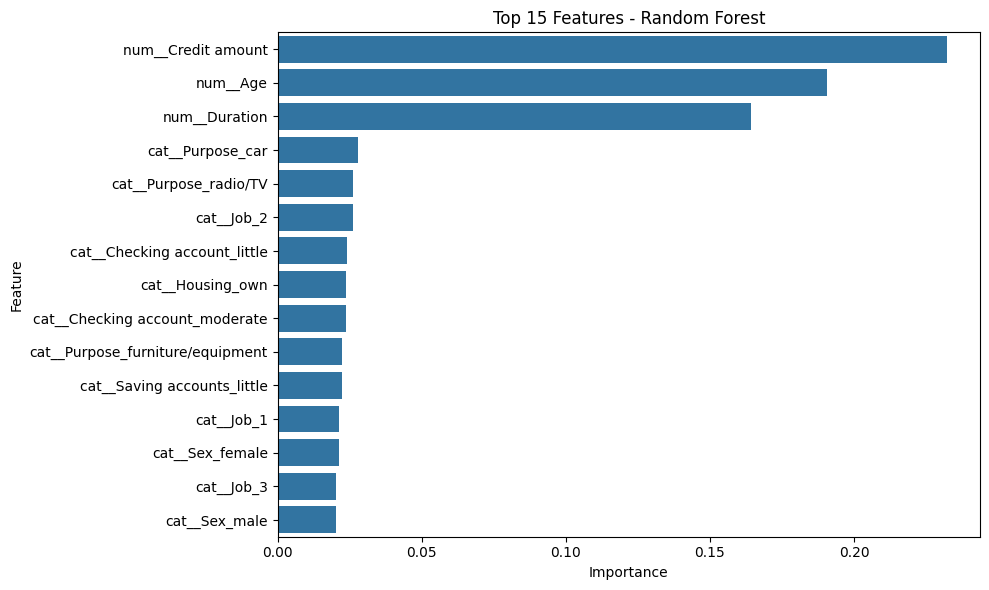

In [46]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [47]:
import joblib

In [48]:
if best_model_name == "Random Forest":
    best_model = random_forest_model
else:
    best_model = logistic_model

joblib.dump(
    best_model,
    "credit_scoring_model.pkl"
)

print("Best model saved successfully! ✅")

Best model saved successfully! ✅


In [50]:
def predict_credit_risk(
    age,
    sex,
    job,
    housing,
    saving_accounts,
    checking_account,
    credit_amount,
    duration,
    purpose
):
    applicant = pd.DataFrame({
        "Age": [age],
        "Sex": [sex],
        "Job": [job],
        "Housing": [housing],
        "Saving accounts": [saving_accounts],
        "Checking account": [checking_account],
        "Credit amount": [credit_amount],
        "Duration": [duration],
        "Purpose": [purpose]
    })

    prediction = best_model.predict(applicant)[0]
    probability = best_model.predict_proba(applicant)[0][1]

    if prediction == 1:
        risk = "Poor Credit Risk"
    else:
        risk = "Good Credit Risk"

    return risk, probability

In [51]:
risk, probability = predict_credit_risk(
    age=30,
    sex="male",
    job=2,
    housing="own",
    saving_accounts="little",
    checking_account="moderate",
    credit_amount=2500,
    duration=12,
    purpose="car"
)

print("Predicted Risk:", risk)
print(f"Poor-risk probability: {probability:.2%}")

Predicted Risk: Good Credit Risk
Poor-risk probability: 14.50%


In [52]:
import joblib

joblib.dump(best_model, "credit_scoring_model.pkl")

print("Model saved successfully! ✅")

Model saved successfully! ✅


In [53]:
import os

print(os.path.getsize("credit_scoring_model.pkl"), "bytes")

7516747 bytes


In [54]:
risk, probability = predict_credit_risk(
    age=30,
    sex="male",
    job=2,
    housing="own",
    saving_accounts="little",
    checking_account="moderate",
    credit_amount=2500,
    duration=12,
    purpose="car"
)

print("Predicted Risk:", risk)
print(f"Poor-risk probability: {probability:.2%}")

Predicted Risk: Good Credit Risk
Poor-risk probability: 14.50%
